1. **Censo de Población y Vivienda 2020**. Cada 10 años, el Instituto Nacional de Estadística
y Geografía (INEGI) levanta el Censo de Población y Vivienda con el objetivo de conocer
diversas características de los habitantes de México y sus viviendas a nivel nacional, estatal,
municipal, por localidad, por grupos de manzanas y hasta por manzana.

    Descarga la base de datos con los principales resultados por localidad (ITER) de 2020 de los Estados Unidos Mexicanos y genera la siguiente información:

In [2]:
import pandas as pd
df = pd.read_csv('Datasets/ITER_NALCSV20.csv')
df.head()

C:\Users\cemh0\AppData\Local\Temp\ipykernel_10648\2903045535.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datasets/ITER_NALCSV20.csv')


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,...,30775898,18307193,15211306,6616141,4047100,1788552,3170894,15108204,852871,*
1,0,Total nacional,0,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,250354,...,47005,8385,18981,1732,1113,12775,14143,51293,7154,*
2,0,Total nacional,0,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,147125,...,25581,5027,11306,971,708,8247,10065,29741,5283,*
3,1,Aguascalientes,0,Total de la entidad Aguascalientes,0,Total de la Entidad,NaN,NaN,NaN,1425607,...,359895,236003,174089,98724,70126,6021,15323,128996,1711,*
4,1,Aguascalientes,0,Total de la entidad Aguascalientes,9998,Localidades de una vivienda,NaN,NaN,NaN,3697,...,732,205,212,48,41,39,62,530,20,*


1.1. **Base de datos a nivel municipio**. Extrae directamente los sub-totales para cada
municipio y usa esta base para responder las siguientes preguntas:
- ¿De qué tamaño es tu base de datos? (considera el número de renglones × columnas y el peso en MB).
- Obtén la población total de la República Mexicana y busca alguna fuente confiable para corroborar tu resultado.
- No filtres ni agregues sobre las localidades para cada municipio. ¿Por qué esto sería una pésima idea?

In [3]:
municipios = df[(df['LOC']==0) & (df['MUN']!=0) & (df['ENTIDAD']!=0)]

# Dimensiones del DataFrame
num_filas, num_columnas = municipios.shape
print(f"Tamaño de la base de datos: {num_filas} filas × {num_columnas} columnas")

# Tamaño en memoria del DataFrame en MB
tamaño_mb = municipios.memory_usage(deep=True).sum() / (1024**2)
print(f"Peso en memoria: {tamaño_mb:.2f} MB")

# Sumar la población total de todos los municipios
poblacion_mexico = municipios["POBTOT"].sum()
print(f"Población total estimada de México: {poblacion_mexico:,}")

Tamaño de la base de datos: 2469 filas × 286 columnas
Peso en memoria: 34.60 MB
Población total estimada de México: 126,014,024


Agregar o filtrar sobre las localidades sería un error porque la base de datos ya contiene información sobre los subtotales de cada municipio, por lo que sería gastar recursos computacionales de forma innecesaria, además, si agregamos o sumamos la población directamente de las localidades podemos estar duplicando o triplicando la cantidad real de población debido a que ya existe información sobre los subtotales de cada municipio y de cada entidad.

1.2. **Análisis de variables socioeconómicas**. Calcula los siguientes indicadores para cada
municipio:
- Porcentaje de población de 5 años y más que habla alguna lengua indígena.
- Porcentaje de población de 15 años y más que es analfabeta.

Ambos porcentajes deben calcularse con respecto a las poblaciones correspondientes de
cada municipio.
- ¿Existe alguna relación entre ambas variables? Para responder, realiza un diagrama
de dispersión.

In [4]:
va_soec = pd.DataFrame(municipios[['NOM_ENT','NOM_MUN']])

cincoymas = municipios['P_5YMAS'].astype(int)
cincoymas_hli = municipios['P5_HLI'].astype(int)

quinceymas = municipios['P_15YMAS'].astype(int)
quinceymas_ana = municipios['P15YM_AN'].astype(int)

va_soec['%P5YM_HLI'] = cincoymas_hli*100/cincoymas
va_soec['%P15YM_AN'] = quinceymas_ana*100/quinceymas

va_soec.head()

,NOM_ENT,NOM_MUN,%P5YM_HLI,%P15YM_AN
6,Aguascalientes,Aguascalientes,0.209139,1.642183
574,Aguascalientes,Asientos,0.047728,3.523404
749,Aguascalientes,Calvillo,0.140441,4.487288
918,Aguascalientes,Cosío,0.045890,3.139545
985,Aguascalientes,Jesús María,0.131835,2.377387


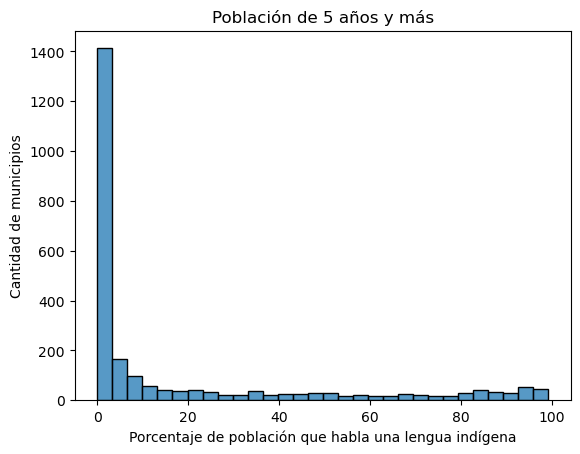

In [5]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.histplot(data=va_soec, x='%P5YM_HLI')

plt.xlabel('Porcentaje de población que habla una lengua indígena') 
plt.ylabel('Cantidad de municipios')
plt.title('Población de 5 años y más')

plt.show()

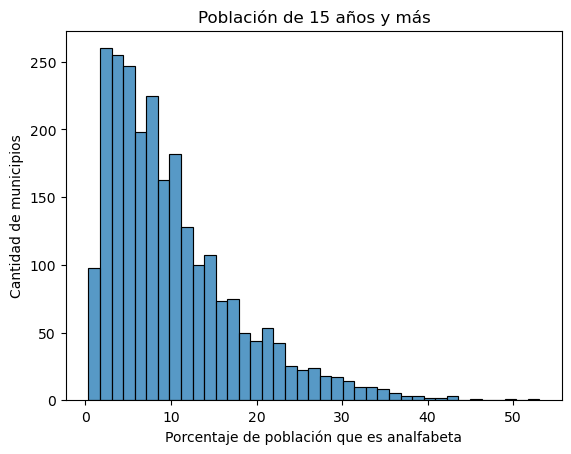

In [6]:
sns.histplot(data=va_soec, x='%P15YM_AN')

plt.xlabel('Porcentaje de población que es analfabeta') 
plt.ylabel('Cantidad de municipios')
plt.title('Población de 15 años y más')

plt.show()

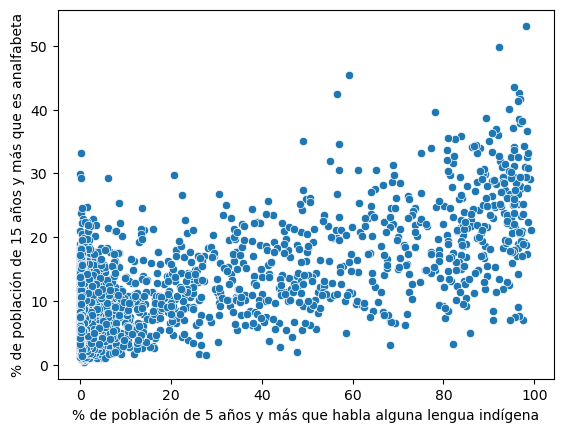

In [7]:
import seaborn as sns
sns.scatterplot(data=va_soec, x='%P5YM_HLI', y='%P15YM_AN')
plt.ylabel('% de población de 15 años y más que es analfabeta')
plt.xlabel('% de población de 5 años y más que habla alguna lengua indígena')
plt.show()

In [8]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(va_soec['%P5YM_HLI'], va_soec['%P15YM_AN'])
print(f"Coeficiente de correlación de Pearson: {corr}")
print(f"P-value: {p_value}")

Coeficiente de correlación de Pearson: 0.7006018378848411
P-value: 0.0


1.3. **Análisis de la distribución de población por entidad federativa**. Realiza un
boxplot o un histograma (o ambos) de la distribución de la población en las entidades
federativas.

- Con base en las gráficas, decide si calcular una media truncada o la mediana y
compárala con la media muestral. Justifica tu elección.
- Calcula un estimador de dispersión de tu elección y justifica su uso.
- Con base en tu análisis, ¿qué puedes concluir sobre la distribución de la población
en las entidades federativas?

In [9]:
entidades = df[(df['LOC']==0) & (df['MUN']==0) & (df['ENTIDAD']!=0)]
entidades['POB_MILL'] = entidades['POBTOT'] / 1000000

C:\Users\cemh0\AppData\Local\Temp\ipykernel_10648\1432619623.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entidades['POB_MILL'] = entidades['POBTOT'] / 1000000


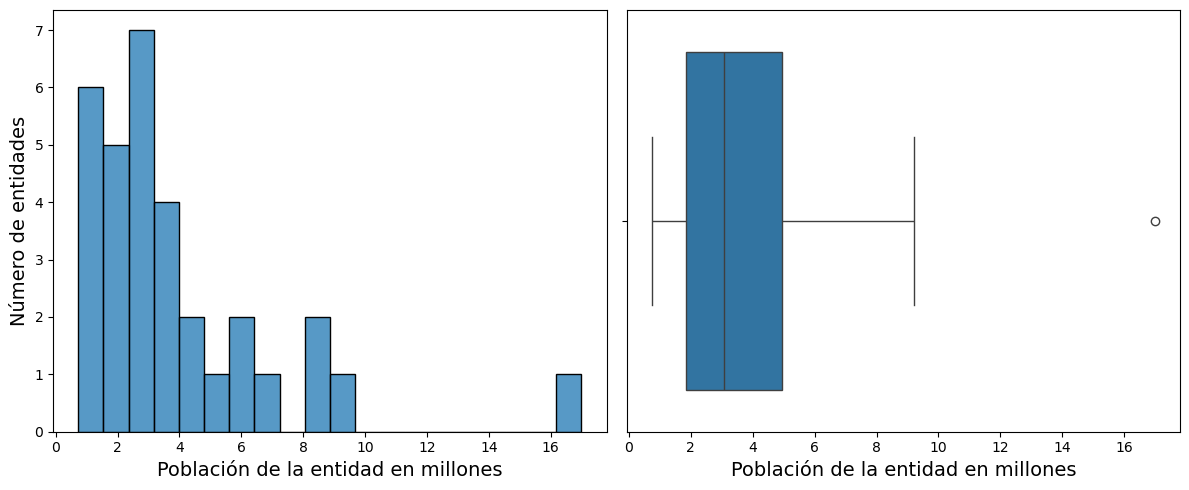

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  


sns.histplot(data=entidades, x='POB_MILL', bins=20, ax=axes[0])
axes[0].set_ylabel('Número de entidades', fontsize=14)
axes[0].set_xlabel('Población de la entidad en millones', fontsize=14)

sns.boxplot(data=entidades, x='POB_MILL', ax=axes[1])
axes[1].set_xlabel('Población de la entidad en millones', fontsize=14)

plt.tight_layout()
plt.show()

Elegimos la mediana y el rango intercuantílico para evitar distorsionar los resultados por estados con poblaciones demasiado grandes

In [11]:
# Calcular la mediana
mediana_poblacion = entidades["POBTOT"].median()

# Calcular la media truncada (eliminando el 10% inferior y superior)
from scipy.stats import trim_mean
media_truncada = trim_mean(entidades["POBTOT"], proportiontocut=0.05)

media = entidades["POBTOT"].mean()

# Calcular IQR
q1 = entidades["POBTOT"].quantile(0.25)
q3 = entidades["POBTOT"].quantile(0.75)
iqr = q3 - q1

std = entidades['POBTOT'].std()

print(f"Mediana: {mediana_poblacion}")
print(f"Media truncada (10%): {media_truncada}")
print(f'Media muestral: {media}')
print(f"IQR: {iqr}")
print(f'Desviación estándar: {std}')

Mediana: 3054892.0
Media truncada (10%): 3609673.8333333335
Media muestral: 3937938.25
IQR: 3095940.25
Desviación estándar: 3278009.0924825086
